# <p><center style="font-family:newtimeroman;font-size:180%;">Alzheimer's Dataset ( 4 class of Images) Analysis & Visualization</center></p>

**<a id="1"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Import Libraries </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [1]:
import os 
import cv2
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from keras.preprocessing.image import ImageDataGenerator
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from mpl_toolkits.axes_grid1 import ImageGrid

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


**<a id="2"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Read Data </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [2]:
images = []
labels = []
for subfolder in tqdm(os.listdir('/kaggle/input/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset')):
    subfolder_path = os.path.join('/kaggle/input/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset', subfolder)
    for folder in os.listdir(subfolder_path):
        subfolder_path2=os.path.join(subfolder_path,folder)
        for image_filename in os.listdir(subfolder_path2):
            image_path = os.path.join(subfolder_path2, image_filename)
            images.append(image_path)
            labels.append(folder)
df = pd.DataFrame({'image': images, 'label': labels})
df



100%|██████████| 2/2 [00:00<00:00,  3.45it/s]


,image,label
0,/kaggle/input/alzheimers-dataset-4-class-of-im...,ModerateDemented
1,/kaggle/input/alzheimers-dataset-4-class-of-im...,ModerateDemented
2,/kaggle/input/alzheimers-dataset-4-class-of-im...,ModerateDemented
3,/kaggle/input/alzheimers-dataset-4-class-of-im...,ModerateDemented
4,/kaggle/input/alzheimers-dataset-4-class-of-im...,ModerateDemented
...,...,...
6395,/kaggle/input/alzheimers-dataset-4-class-of-im...,MildDemented
6396,/kaggle/input/alzheimers-dataset-4-class-of-im...,MildDemented
6397,/kaggle/input/alzheimers-dataset-4-class-of-im...,MildDemented
6398,/kaggle/input/alzheimers-dataset-4-class-of-im...,MildDemented


In [3]:
class_mapping = {
    'NonDemented': 'Cognitively normal',
    'VeryMildDemented': 'Early mild cognitive impairment',
    'MildDemented': 'Late mild cognitive impairment',
    'ModerateDemented': 'Alzheimer_s disease'
}

# Rename the classes in the 'class' column
df['label'] = df['label'].map(class_mapping)

In [4]:
df

,image,label
0,/kaggle/input/alzheimers-dataset-4-class-of-im...,Alzheimer_s disease
1,/kaggle/input/alzheimers-dataset-4-class-of-im...,Alzheimer_s disease
2,/kaggle/input/alzheimers-dataset-4-class-of-im...,Alzheimer_s disease
3,/kaggle/input/alzheimers-dataset-4-class-of-im...,Alzheimer_s disease
4,/kaggle/input/alzheimers-dataset-4-class-of-im...,Alzheimer_s disease
...,...,...
6395,/kaggle/input/alzheimers-dataset-4-class-of-im...,Late mild cognitive impairment
6396,/kaggle/input/alzheimers-dataset-4-class-of-im...,Late mild cognitive impairment
6397,/kaggle/input/alzheimers-dataset-4-class-of-im...,Late mild cognitive impairment
6398,/kaggle/input/alzheimers-dataset-4-class-of-im...,Late mild cognitive impairment


**<a id="3"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Visualization & Analysis of Dataset </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [5]:
# Number of photos in each class
df['label'].value_counts()

label
Cognitively normal                 3200
Early mild cognitive impairment    2240
Late mild cognitive impairment      896
Alzheimer_s disease                  64
Name: count, dtype: int64

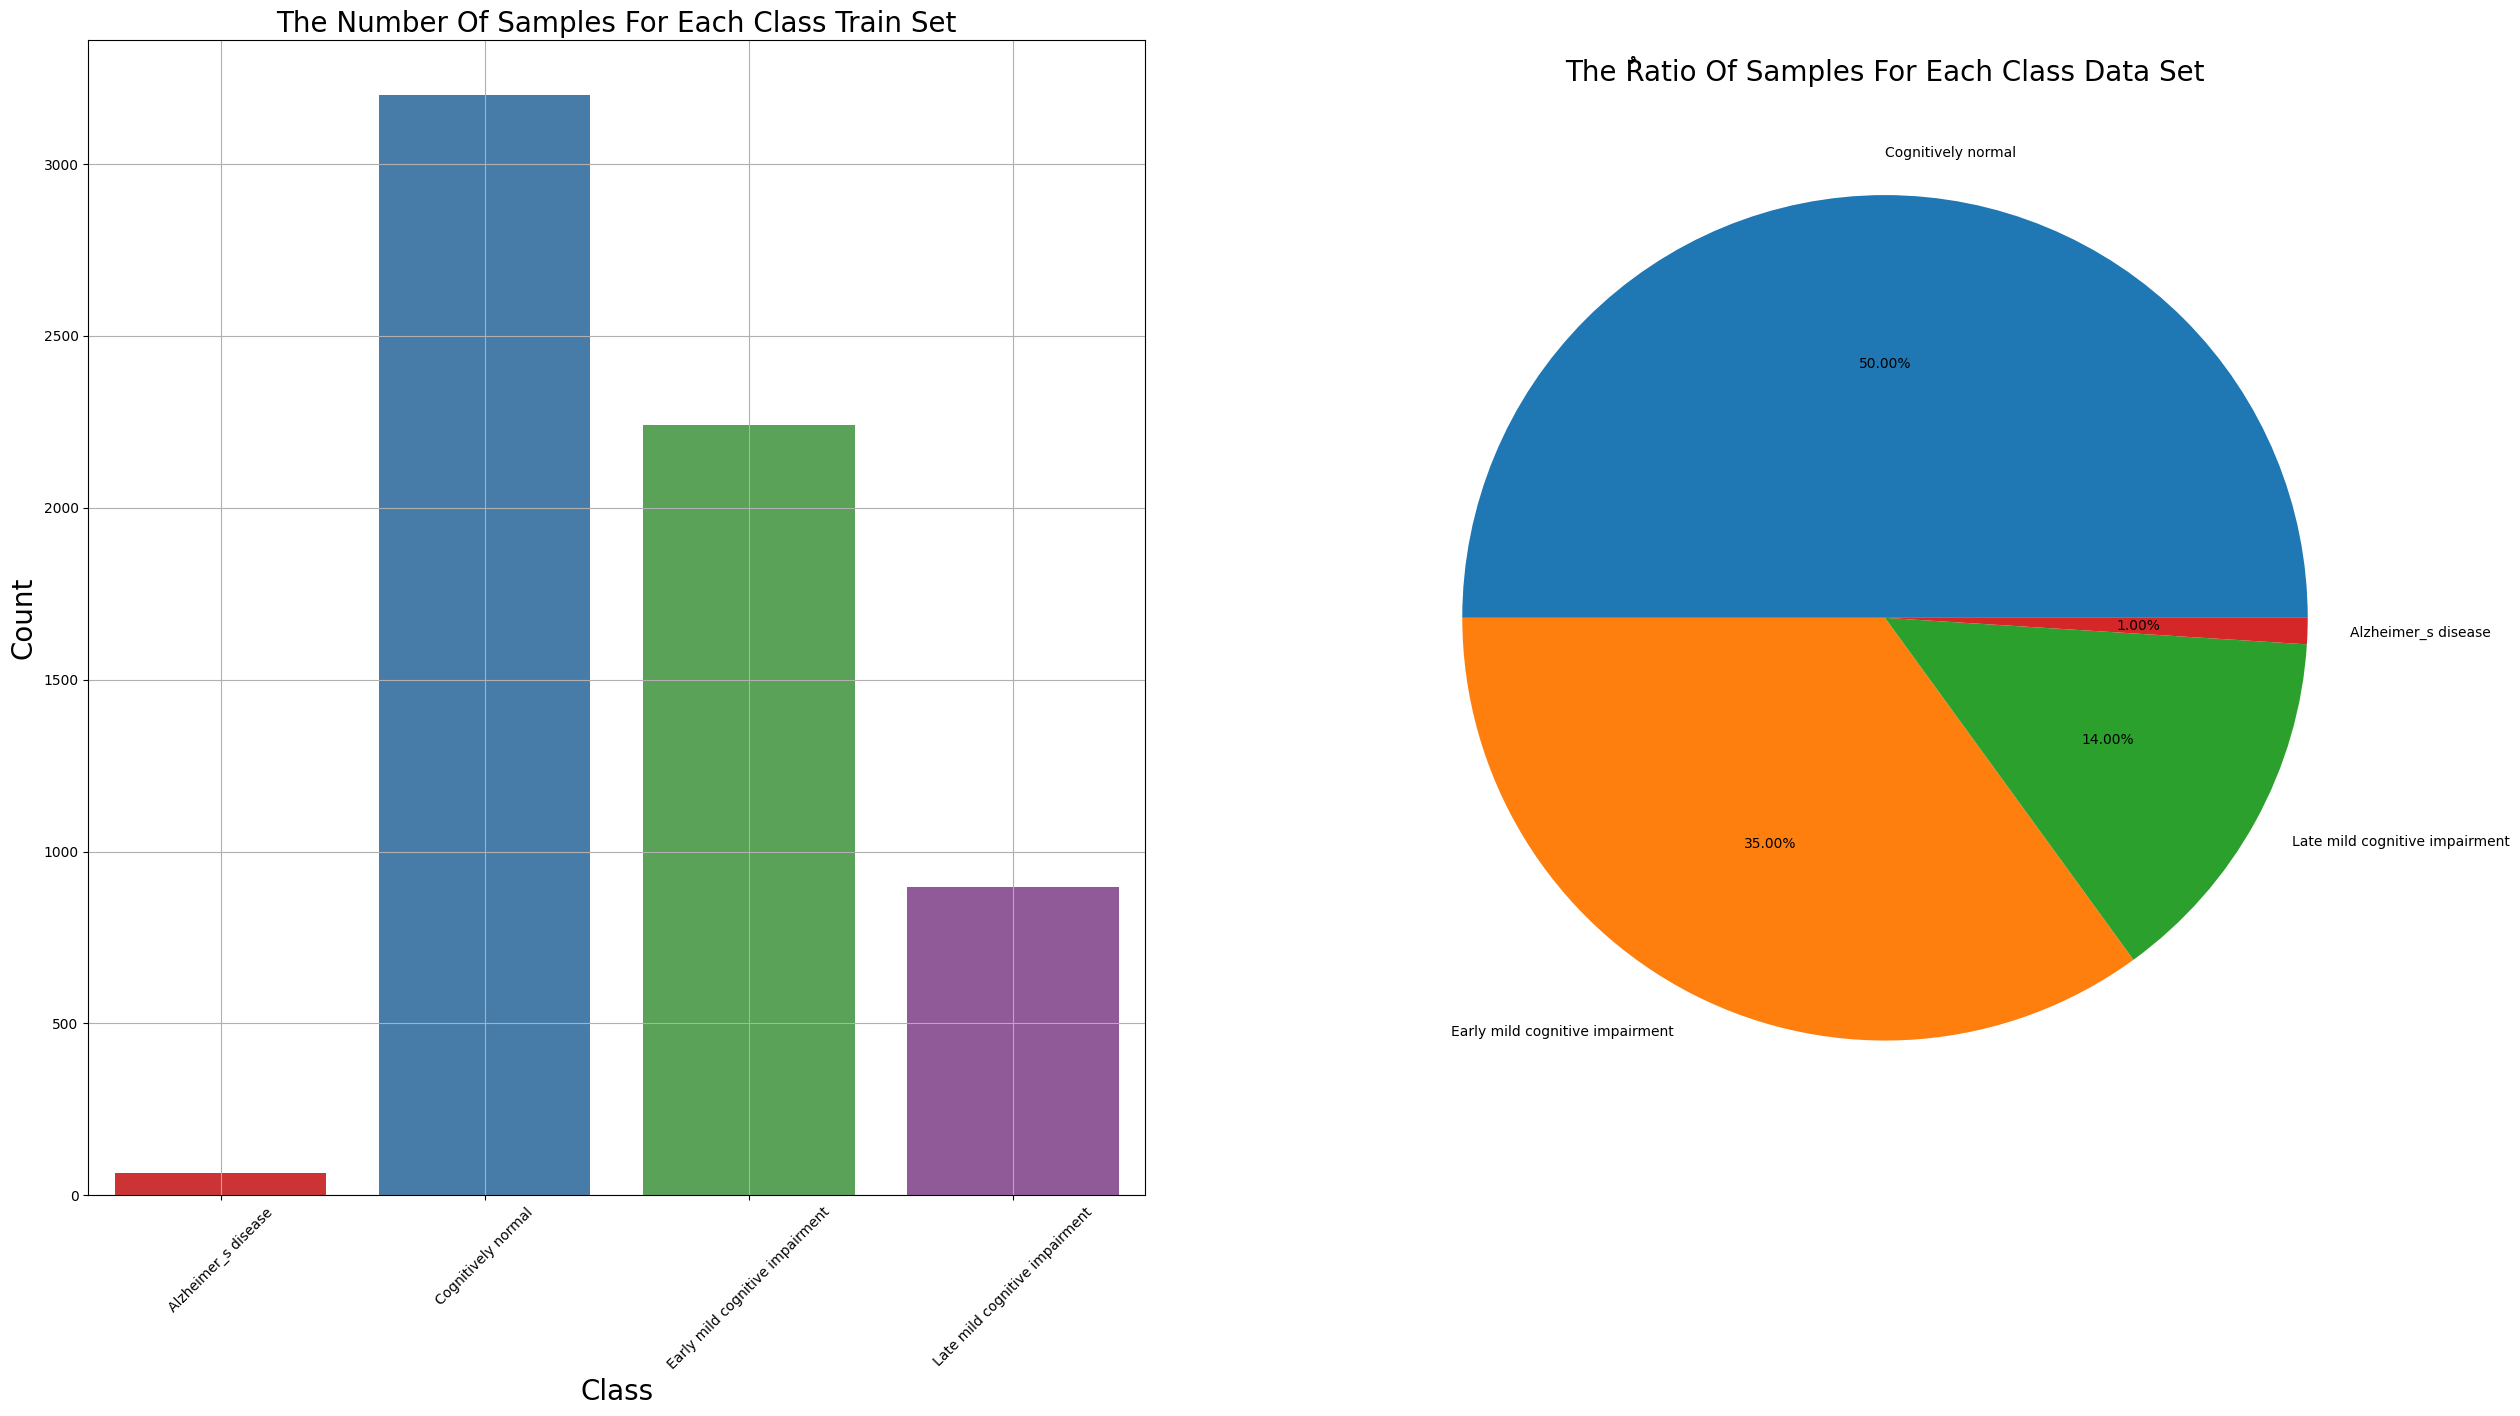

In [6]:
 #Visualizing class distribution using count plot and pie chart
plt.figure(figsize=(30, 15))

# Count Plot
plt.subplot(1, 2, 1)
ax = sns.countplot(x='label', data=df, palette='Set1')
ax.set_xlabel("Class", fontsize=20)
ax.set_ylabel("Count", fontsize=20)
plt.title('The Number Of Samples For Each Class Train Set', fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)

# Pie Chart
plt.subplot(1, 2, 2)
plt.pie(x=df['label'].value_counts(), autopct='%1.2f%%', labels=df['label'].value_counts().index, radius=1)
plt.title('The ٌRatio Of Samples For Each Class Data Set',fontsize=20)

plt.show()

In [7]:
Size=(176,176)
work_dr = ImageDataGenerator(
    rescale = 1./255
)
train_data_gen = work_dr.flow_from_dataframe(df,x_col='image',y_col='label', target_size=Size, batch_size=6500, shuffle=False)

Found 6400 validated image filenames belonging to 4 classes.


In [8]:
train_data, train_labels = train_data_gen.next()

In [9]:
class_num=np.sort(['Alzheimer_s disease','Cognitively normal','Early mild cognitive impairment','Late mild cognitive impairment'])
class_num

array(['Alzheimer_s disease', 'Cognitively normal',
       'Early mild cognitive impairment',
       'Late mild cognitive impairment'], dtype='<U31')

In [10]:
sm = SMOTE(random_state=42)
train_data, train_labels = sm.fit_resample(train_data.reshape(-1, 176 * 176 * 3), train_labels)
train_data = train_data.reshape(-1, 176,176, 3)
print(train_data.shape, train_labels.shape)

(12800, 176, 176, 3) (12800, 4)


In [11]:
labels = [class_num[i] for i in np.argmax(train_labels, axis=1)]
label_series = pd.Series(labels)
label_series.value_counts()

Alzheimer_s disease                3200
Cognitively normal                 3200
Early mild cognitive impairment    3200
Late mild cognitive impairment     3200
Name: count, dtype: int64

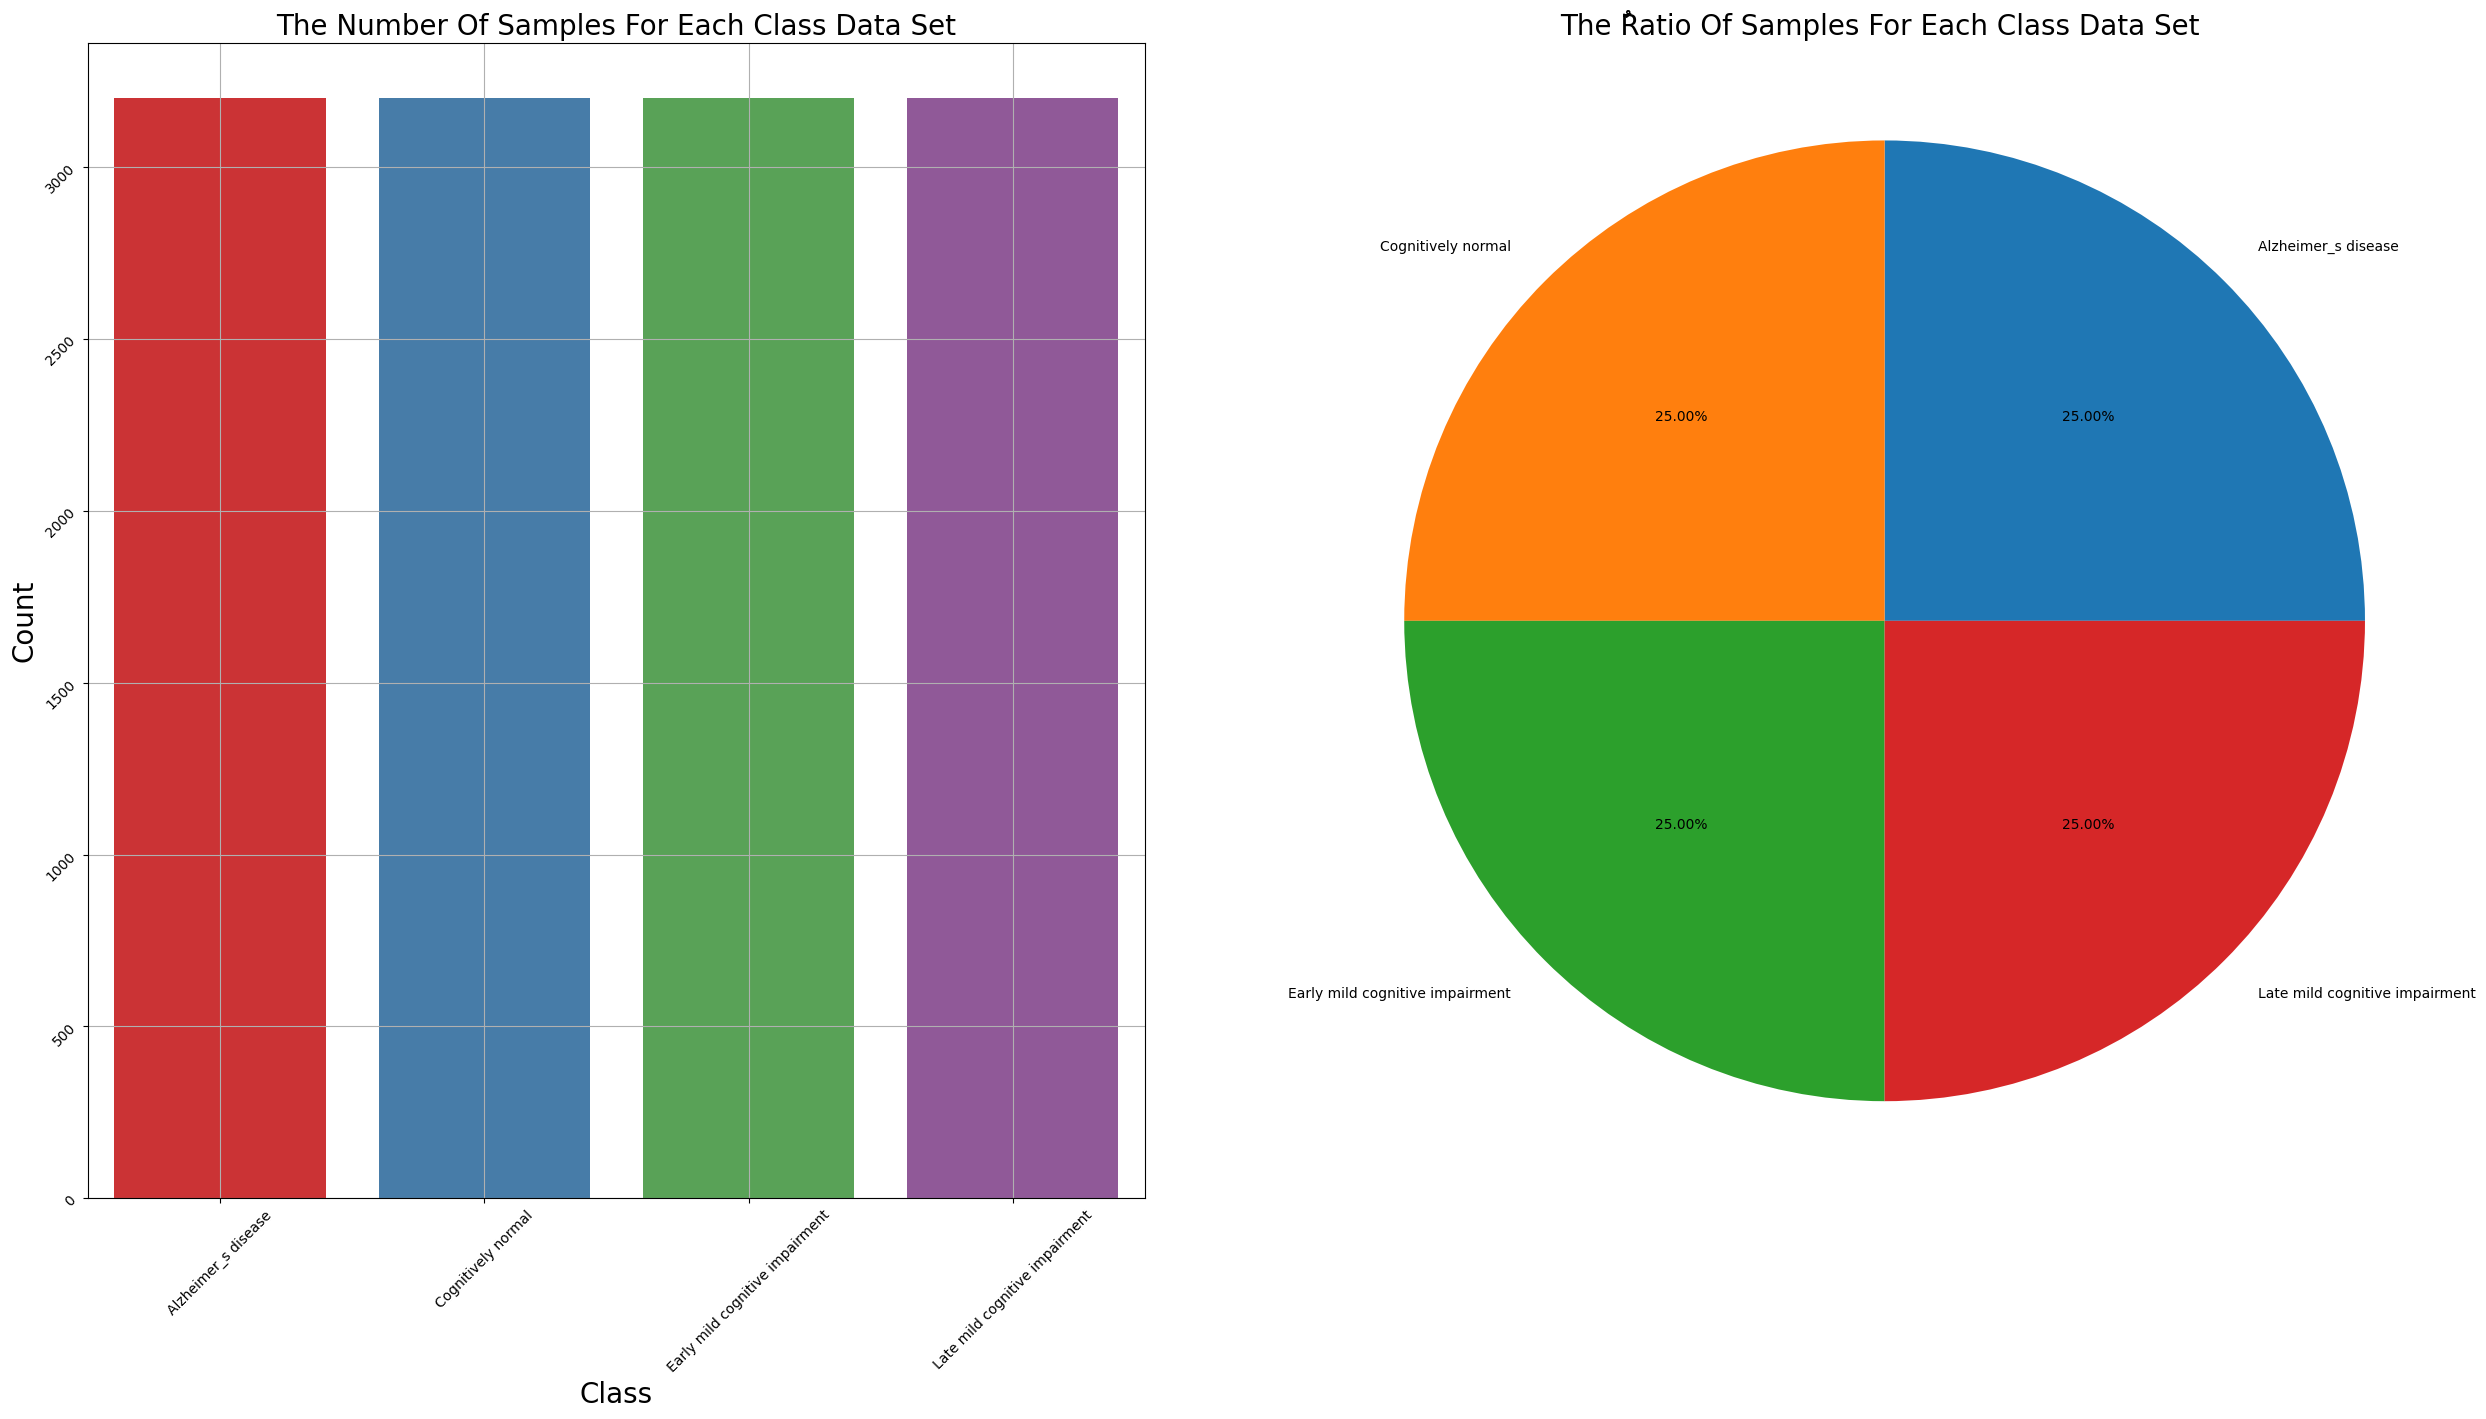

In [12]:
# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(30, 15))

# Count Plot
axs[0].set_title('The Number Of Samples For Each Class Data Set',fontsize=20)
sns.countplot(x=label_series, palette='Set1', ax=axs[0])
axs[0].set_xlabel("Class", fontsize=20)
axs[0].set_ylabel("Count", fontsize=20)
axs[0].grid(True)
axs[0].tick_params(rotation=45)

# Pie Chart
axs[1].set_title('The ٌRatio Of Samples For Each Class Data Set ',fontsize=20)
axs[1].pie(x=label_series.value_counts(), autopct='%1.2f%%', labels=label_series.value_counts().index, radius=1)
axs[1].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.show()


In [13]:
labels=np.array(labels)
X_train, X_test1, y_train, y_test1 = train_test_split(train_data,labels, test_size=0.3, random_state=42,shuffle=True,stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_test1,y_test1, test_size=0.5, random_state=42,shuffle=True,stratify=y_test1)
print('X_train shape is ' , X_train.shape)
print('X_test shape is ' , X_test.shape)
print('X_val shape is ' , X_val.shape)
print('y_train shape is ' , y_train.shape)
print('y_test shape is ' , y_test.shape)
print('y_val shape is ' , y_val.shape)

X_train shape is  (8960, 176, 176, 3)
X_test shape is  (1920, 176, 176, 3)
X_val shape is  (1920, 176, 176, 3)
y_train shape is  (8960,)
y_test shape is  (1920,)
y_val shape is  (1920,)


In [14]:
pd.DataFrame(y_train).value_counts()

Alzheimer_s disease                2240
Cognitively normal                 2240
Early mild cognitive impairment    2240
Late mild cognitive impairment     2240
Name: count, dtype: int64

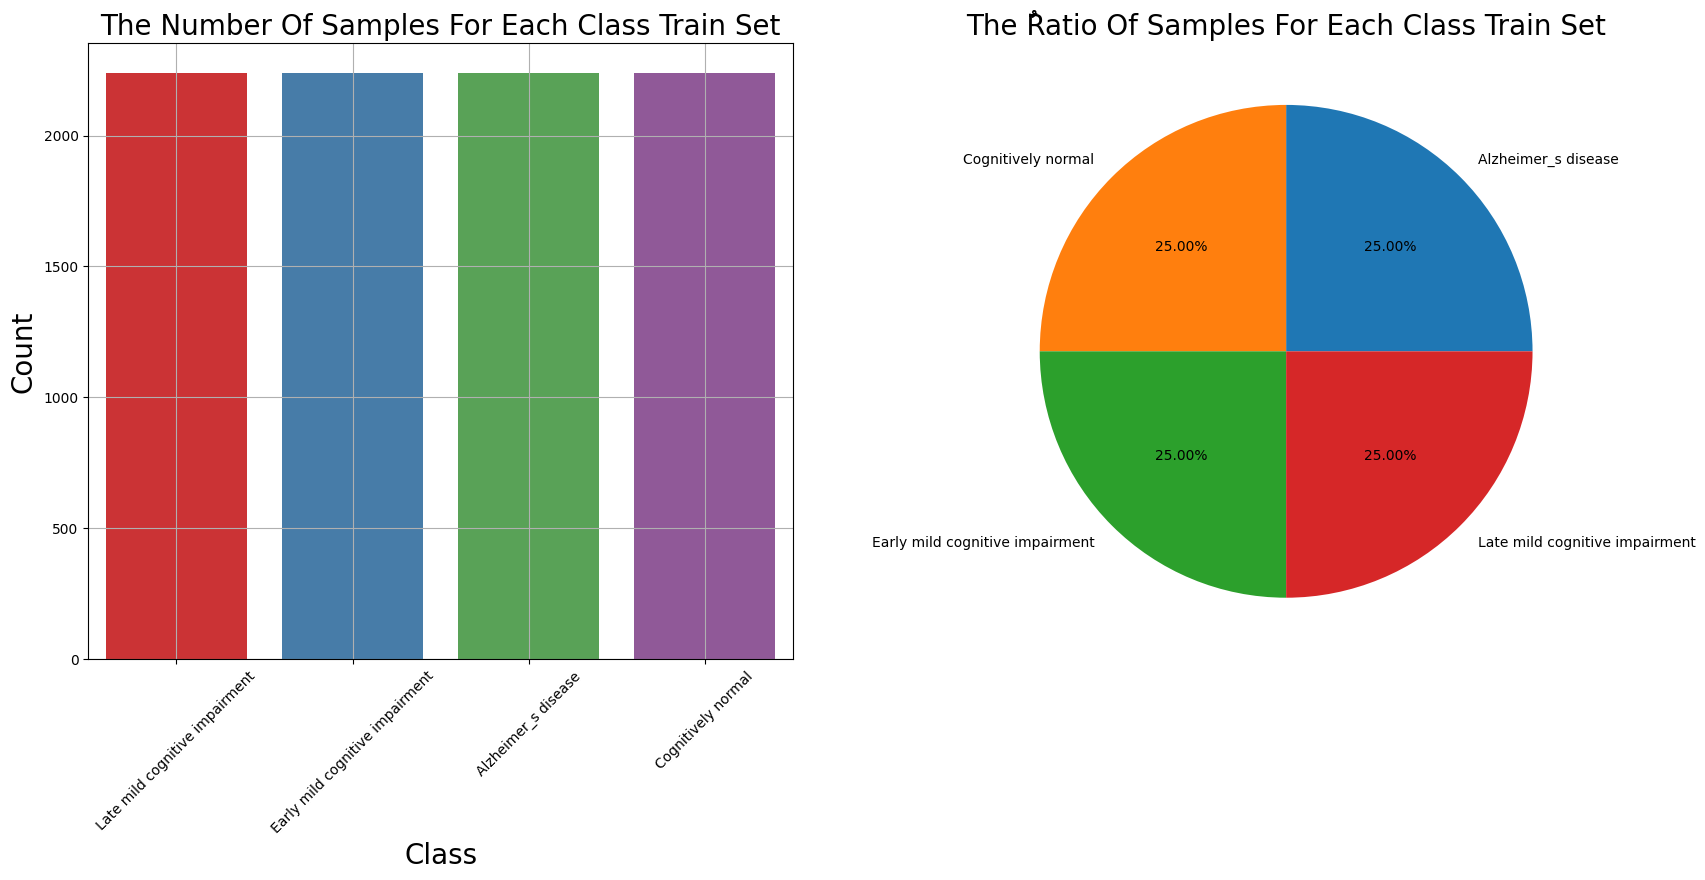

In [15]:
# Count Plot
plt.figure(figsize=(20, 8))
plt.subplot(1,2,1)
ax = sns.countplot(x=y_train, palette='Set1')
ax.set_xlabel("Class", fontsize=20)
ax.set_ylabel("Count", fontsize=20)
plt.title('The Number Of Samples For Each Class Train Set', fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)

# Pie Chart
plt.subplot(1,2,2)
plt.pie(x=pd.DataFrame(y_train).value_counts(), autopct='%1.2f%%', labels=class_num, radius=1)
plt.title('The ٌRatio Of Samples For Each Class Train Set', fontsize=20)
plt.show()

In [16]:
pd.DataFrame(y_test).value_counts()

Alzheimer_s disease                480
Cognitively normal                 480
Early mild cognitive impairment    480
Late mild cognitive impairment     480
Name: count, dtype: int64

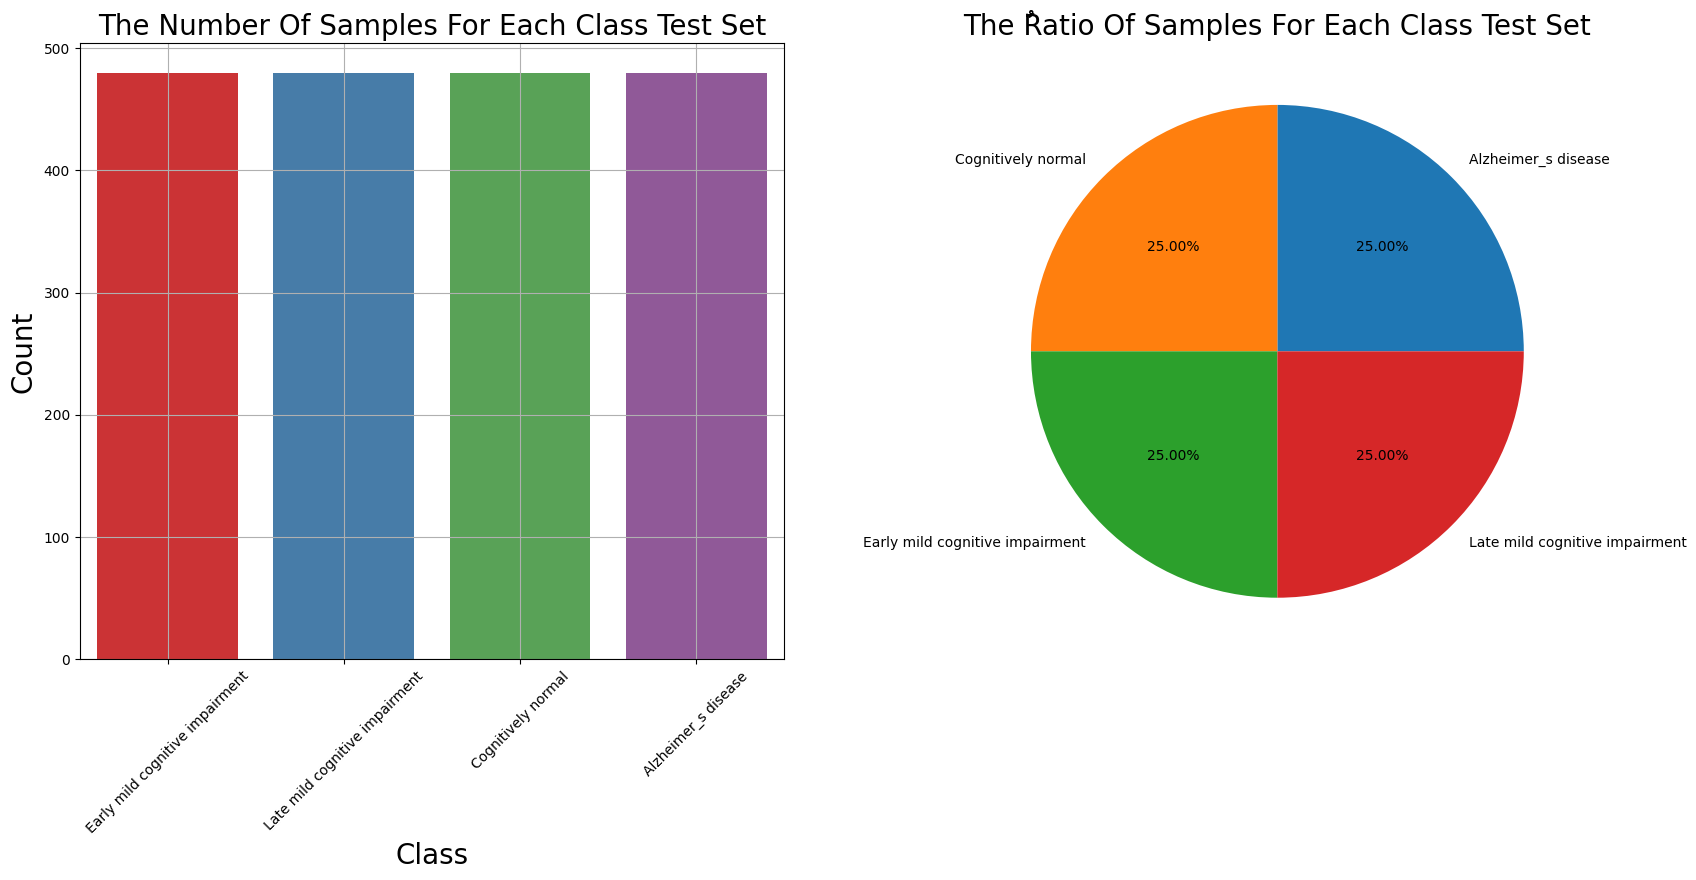

In [17]:
# Assuming test_y is a list
# Count Plot
plt.figure(figsize=(20, 8))
plt.subplot(1,2,1)
ax = sns.countplot(x=y_test, palette='Set1')
ax.set_xlabel("Class", fontsize=20)
ax.set_ylabel("Count", fontsize=20)
plt.title('The Number Of Samples For Each Class Test Set', fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)

# Pie Chart
plt.subplot(1,2,2)
plt.pie(x=pd.DataFrame(y_test).value_counts(), autopct='%1.2f%%', labels=class_num,radius=1)
plt.title('The ٌRatio Of Samples For Each Class Test Set', fontsize=20)
plt.show()

In [18]:
pd.DataFrame(y_val).value_counts()

Alzheimer_s disease                480
Cognitively normal                 480
Early mild cognitive impairment    480
Late mild cognitive impairment     480
Name: count, dtype: int64

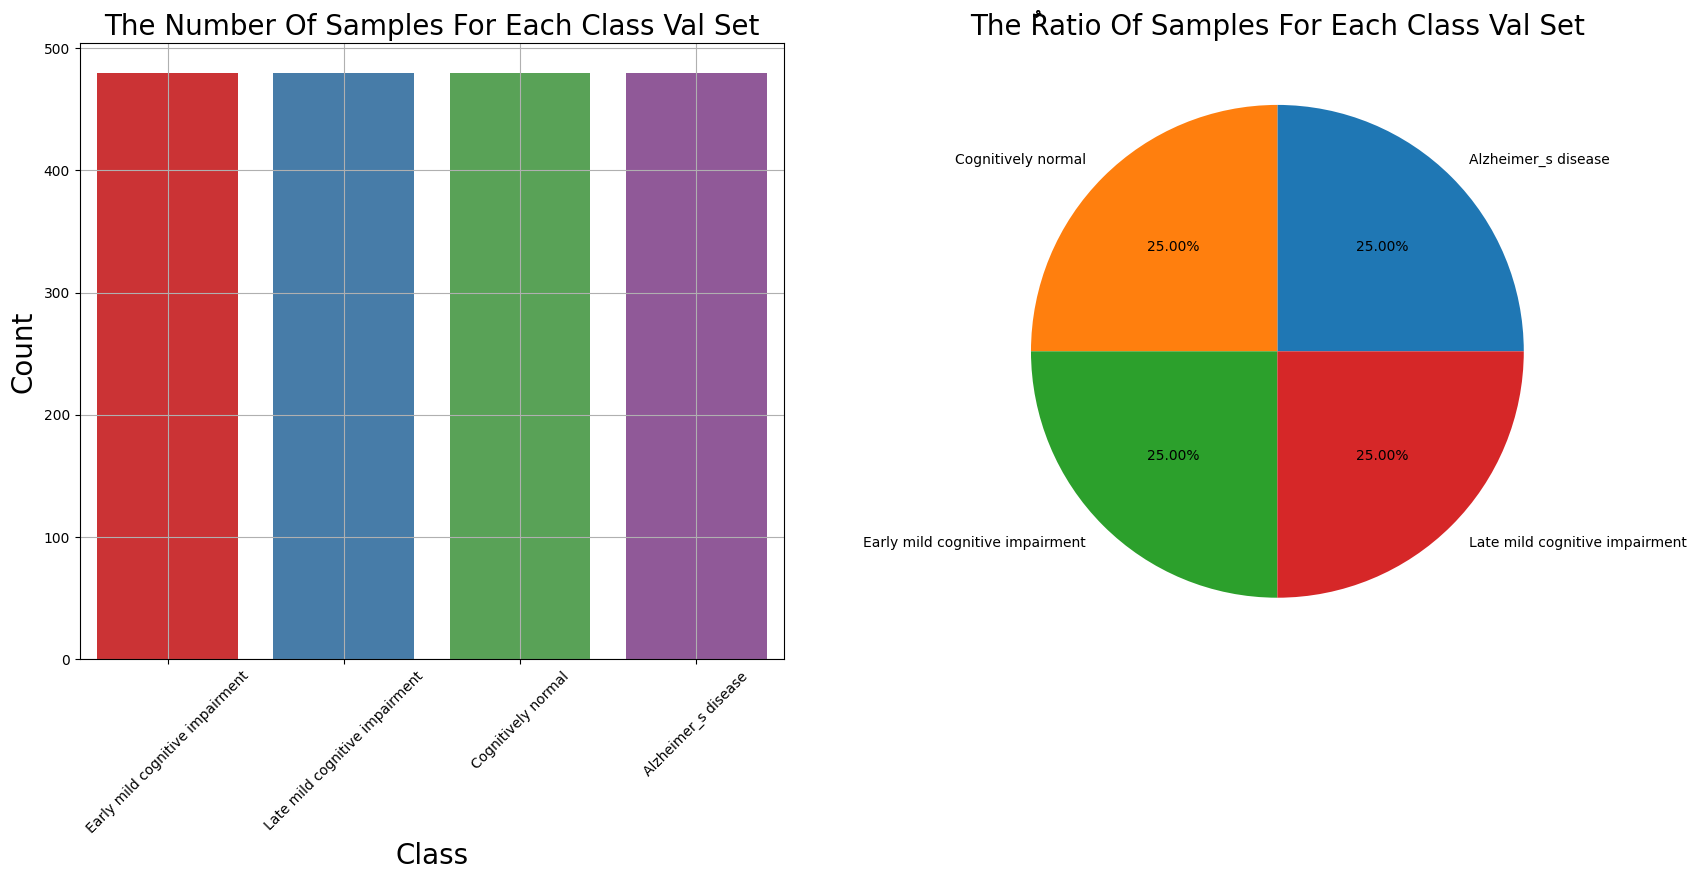

In [19]:
# Count Plot
plt.figure(figsize=(20, 8))
plt.subplot(1,2,1)
ax = sns.countplot(x=y_val, palette='Set1')
ax.set_xlabel("Class", fontsize=20)
ax.set_ylabel("Count", fontsize=20)
plt.title('The Number Of Samples For Each Class Val Set', fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)

# Pie Chart
plt.subplot(1,2,2)
plt.pie(x=pd.DataFrame(y_val).value_counts(), autopct='%1.2f%%', labels=class_num, radius=1)
plt.title('The ٌRatio Of Samples For Each Class Val Set', fontsize=20)
plt.show()

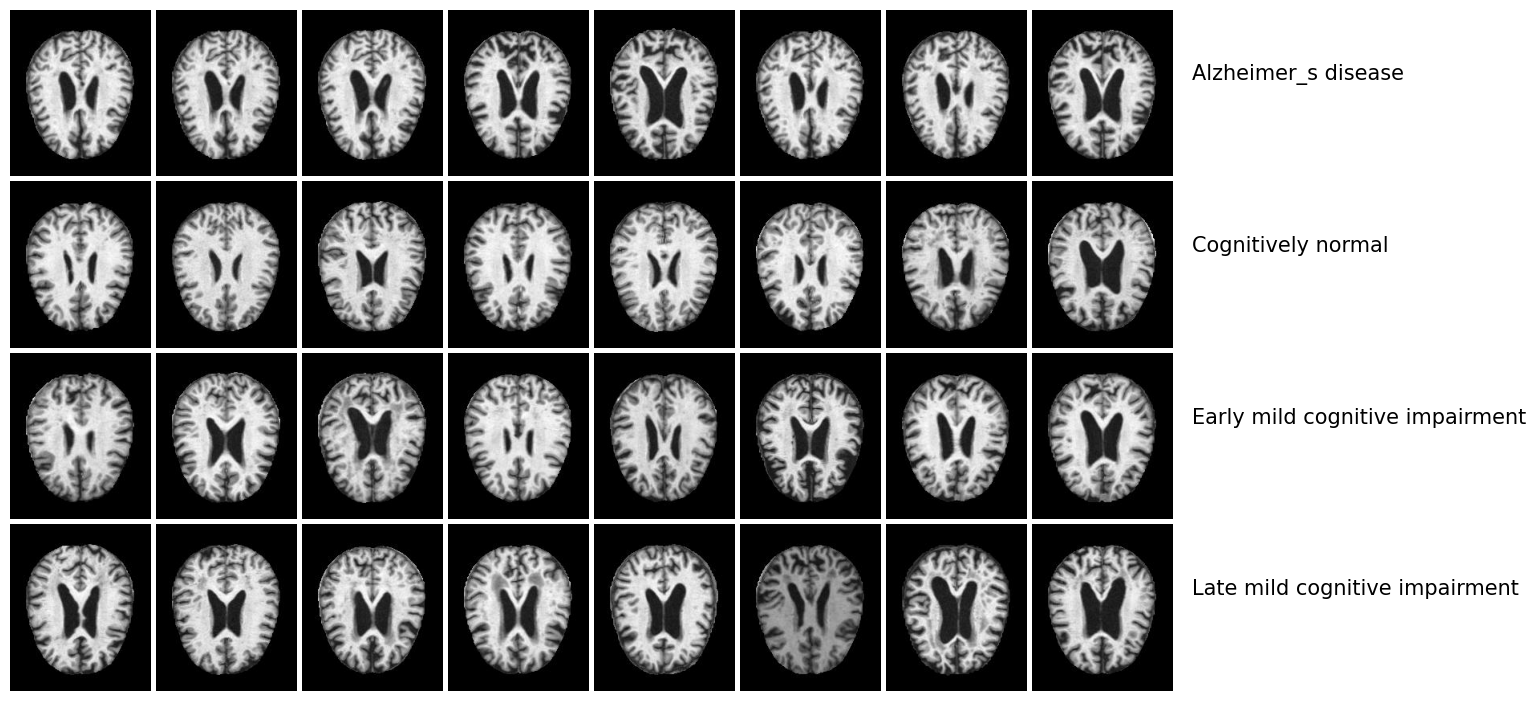

In [20]:
NUM_IMAGES_PER_CLASS = 8
NUM_CATEGORIES=4
fig = plt.figure(1, figsize=(15, 15))
grid = ImageGrid(fig, 111, nrows_ncols=(NUM_CATEGORIES, NUM_IMAGES_PER_CLASS), axes_pad=0.05)
i = 0

for category_id, category in enumerate(class_num):
    for filepath in df['image'][df['label'] == category][:NUM_IMAGES_PER_CLASS]:
        ax = grid[i]
        img = cv2.imread(filepath)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img / 255)
        ax.axis('off')
        
        if i % NUM_IMAGES_PER_CLASS == NUM_IMAGES_PER_CLASS - 1:
            ax.text(200, 80, category, verticalalignment='center', size=15)
        
        i += 1

plt.show()